<div dir="rtl" style="text-align:right">

# תרגול 6  
## Least Squares, התאמת עקומות, Classification והערכת מודלים



- מודלים לינאריים בפרמטרים
- בניית מטריצת Design Matrix
- פתרון Least Squares עם pseudo-inverse
- התאמת פולינומים
- שאריות / residuals
- underfitting ו־overfitting
- Ridge / Lasso 

- Decision Tree Classifier
- Train/Test Split
- Confusion Matrix
- Accuracy, Precision, Recall, F1
- ROC Curve ו־AUC
- Cross Validation


</div>

<div dir="rtl" style="text-align:right">

## הוראות עבודה

במחברת זו יש תרגילים עם תאי `TODO`.  
אחרי כל תרגיל יש פתרון מוסתר תחת כפתור **פתרון מוסתר**.

מומלץ קודם לנסות לבד, ורק אחר כך לפתוח את הפתרון.

</div>

<div dir="rtl" style="text-align:right">

## 0. טעינת ספריות

</div>

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

np.random.seed(42)

In [56]:
def regression_metrics(y_true, y_pred):
    """Return common regression metrics as a dictionary."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def plot_confusion_matrix_basic(cm, labels=("Class 0", "Class 1"), title="Confusion Matrix"):
    """Plot a confusion matrix with matplotlib only."""
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.show()


def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """Plot decision boundary for a 2D classifier."""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.8)
    plt.xlabel("feature_1")
    plt.ylabel("feature_2")
    plt.title(title)
    plt.show()

<div dir="rtl" style="text-align:right">

#  Least Squares והתאמת עקומות

נתחיל מדאטה סינתטי.  
אנחנו ניצור נקודות `x, y` מתוך פונקציה פולינומית עם רעש.

המטרה: להבין איך מודל פולינומי יכול להיות **לא לינארי ב־x**, אבל עדיין **לינארי בפרמטרים**.

לדוגמה:

</div>


$$
y(x) = b_0 + b_1x + b_2x^2
$$
<div dir="rtl" style="text-align:right">


המודל לא לינארי ב־x בגלל $x^2$, אבל הוא לינארי בפרמטרים $b_0,b_1,b_2$.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 1 — יצירת דאטה ו־Scatter Plot

צרו דאטה לפי הקוד החלקי.  
לאחר מכן ציירו Scatter Plot של `x` מול `y`.

שאלות:

1. האם הקשר נראה לינארי?
2. האם יש רעש?
3. האם מודל של קו ישר יספיק?

</div>

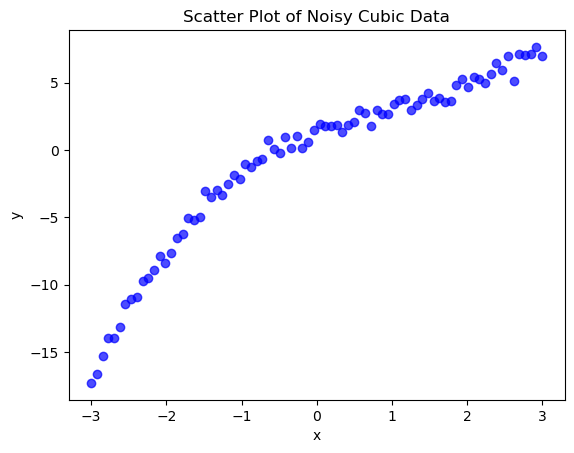

In [57]:
# TODO: צרו x בין -3 ל-3, עם 80 נקודות
x = np.linspace(-3, 3, 80)

# TODO: צרו רעש נורמלי עם ממוצע 0 וסטיית תקן 0.5, באורך 80
noise = np.random.normal(0, 0.5, 80)

# הפונקציה האמיתית, שאותה הסטודנטים לא תמיד יודעים במציאות
y = 1.5 + 2*x - 0.7*x**2 + 0.25*x**3 + noise

# TODO: ציירו scatter plot
plt.scatter(x, y, color="blue", alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot of Noisy Cubic Data")
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
x = np.linspace(-3, 3, 80)
noise = np.random.normal(loc=0, scale=1.2, size=len(x))
y = 1.5 + 2*x - 0.7*x**2 + 0.25*x**3 + noise

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Regression Data")
plt.show()
```

הקשר אינו קו ישר מושלם. יש מבנה לא לינארי ורעש. לכן קו ישר כנראה יהיה מודל פשוט מדי.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 2 — Design Matrix למודל פולינומי

נרצה להתאים מודל:

</div>

$$
y(x) = b_0 + b_1x + b_2x^2 + b_3x^3
$$


<div dir="rtl" style="text-align:right">

נבנה מטריצה $A$ שבה כל שורה מתאימה לדוגמה אחת:

</div>

$$
A = [1, x, x^2, x^3]
$$


<div dir="rtl" style="text-align:right">

ואז נפתור:

</div>

$$
A b \approx y
$$


<div dir="rtl" style="text-align:right">

משימות:

1. בנו Design Matrix עם העמודות: `1`, `x`, `x²`, `x³`.
2. הדפיסו את הצורה של המטריצה.
3. בדקו שהצורה היא `(80, 4)`.

</div>

In [58]:
# TODO: בנו Design Matrix ידנית
A = np.column_stack((np.ones_like(x), x, x**2, x**3))

# TODO: הדפיסו את הצורה
print("Design Matrix Shape:", A.shape)  
print("First 10 rows of Design Matrix:\n", A[:10])

Design Matrix Shape: (80, 4)
First 10 rows of Design Matrix:
 [[  1.          -3.           9.         -27.        ]
 [  1.          -2.92405063   8.5500721  -25.00084375]
 [  1.          -2.84810127   8.11168082 -23.10288841]
 [  1.          -2.7721519    7.68482615 -21.3035054 ]
 [  1.          -2.69620253   7.26950809 -19.60006612]
 [  1.          -2.62025316   6.86572665 -17.98994197]
 [  1.          -2.5443038    6.47348181 -16.47050436]
 [  1.          -2.46835443   6.09277359 -15.03912469]
 [  1.          -2.39240506   5.72360199 -13.69317437]
 [  1.          -2.3164557    5.36596699 -12.43002481]]


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
A = np.column_stack([
    np.ones_like(x),
    x,
    x**2,
    x**3,
])

print(A.shape)
print(A[:5])
```

כל שורה היא דוגמה, וכל עמודה היא פיצ׳ר פולינומי.  
המקדמים $b_0,b_1,b_2,b_3$ הם הפרמטרים שהמודל ילמד.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 3 — פתרון Least Squares עם pseudo-inverse

נפתור:

$$
b = A^+y
$$

כאשר $A^+$ הוא ה־pseudo-inverse של $A$.

משימות:

1. חשבו את המקדמים `b` בעזרת `np.linalg.pinv`.
2. חשבו תחזיות `y_hat`.
3. ציירו את הנקודות ואת העקומה המותאמת.

</div>

Coefficients: [ 1.36825737  2.1658579  -0.67730049  0.2214618 ]


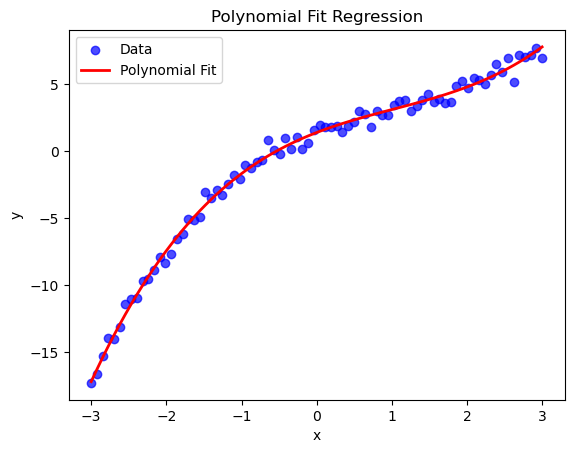

In [59]:
# TODO: מצאו את המקדמים

b = np.linalg.pinv(A) @ y
# b = np.linalg.pinv(A.T @ A) @ A.T @ y

# TODO: חשבו תחזיות
y_hat = A @ b

# TODO: הדפיסו מקדמים וציירו התאמה
print("Coefficients:", b)
plt.scatter(x, y, color="blue", alpha=0.7, label="Data")
plt.plot(x, y_hat, color="red", label="Polynomial Fit", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Fit Regression")
plt.legend()
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
b = np.linalg.pinv(A) @ y
print("Coefficients:", b)

y_hat = A @ b

plt.scatter(x, y, label="data")
plt.plot(x, y_hat, label="degree 3 fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Least Squares Polynomial Fit")
plt.legend()
plt.show()
```

זה פתרון Least Squares ידני.  
המודל מחפש מקדמים שמקטינים את סכום ריבועי השאריות.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 4 — Residuals ומדדי רגרסיה

חשבו את השאריות:

$$
residual = y - \hat{y}
$$

לאחר מכן חשבו:

- MAE
- RMSE
- R²

וציירו:

1. Histogram של השאריות.
2. Scatter של התחזית מול השאריות.

</div>

Regression Metrics: {'MAE': 0.36970189483463856, 'RMSE': np.float64(0.4556715393083433), 'R2': 0.9948017716845865}
MAE: 0.3697, RMSE: 0.4557, R2: 0.9948


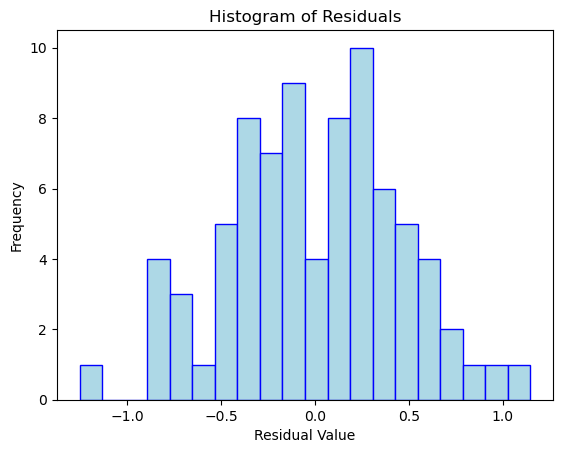

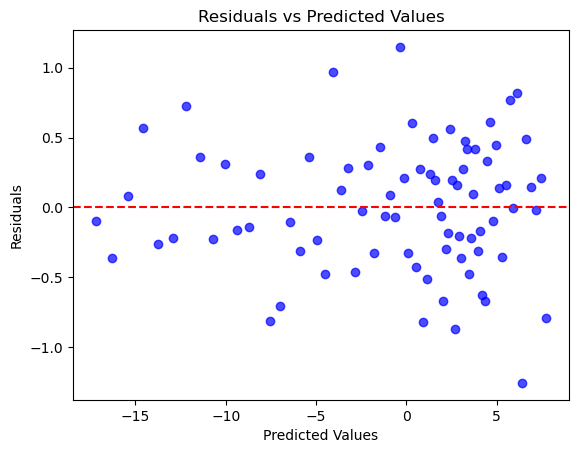

In [60]:
# TODO: חשבו residuals ומדדים
residuals = y - y_hat

# TODO: השתמשו בפונקציה regression_metrics
metrics = regression_metrics(y, y_hat)
print("Regression Metrics:", metrics)

mae = metrics["MAE"]
rmse = metrics["RMSE"]
r2 = metrics["R2"]
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

# TODO: ציירו histogram של residuals
plt.hist(residuals, bins=20, color="lightblue", edgecolor="blue")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# TODO: ציירו residuals vs predicted
plt.scatter(y_hat, residuals, color="blue", alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
residuals = y - y_hat
print(regression_metrics(y, y_hat))

plt.hist(residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

plt.scatter(y_hat, residuals)
plt.axhline(0)
plt.xlabel("Predicted y")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()
```

היינו רוצים שהשאריות יהיו סביב 0 וללא תבנית חזקה.  
אם יש תבנית ברורה, ייתכן שהמודל לא מתאים מספיק לדאטה.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 5 — השוואת דרגות פולינום: Underfitting / Overfitting

נשווה מודלים בדרגות שונות:

- degree 1 — קו ישר
- degree 3 — קרוב למבנה האמיתי
- degree 12 — מודל מורכב מדי

משימות:

1. חלקו את הדאטה ל־train/test.
2. אמנו פולינומים בדרגות `1, 3, 12`.
3. חשבו RMSE על train ועל test.
4. ציירו את ההתאמות.

</div>

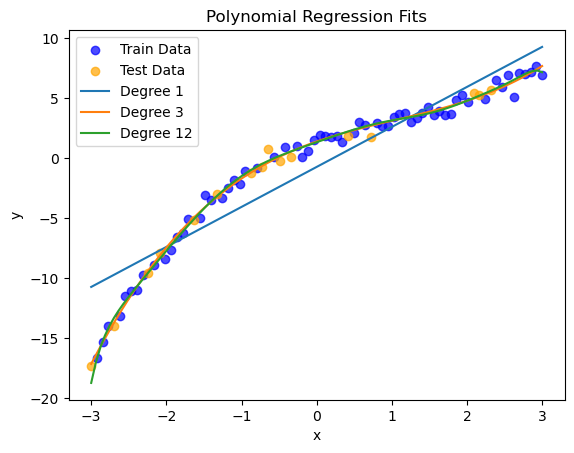

In [63]:
# TODO: חלקו ל-train/test
from xml.parsers.expat import model

X = x.reshape(-1, 1)  # Reshape for sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: עבור כל degree ב-[1, 3, 12], אמנו pipeline:
# PolynomialFeatures(degree=degree, include_bias=False) + LinearRegression()
degrees = [1, 3, 12]
results = []
models = {}
x_grid = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

plt.scatter(X_train, y_train, color="blue", alpha=0.7, label="Train Data")
plt.scatter(X_test, y_test, color="orange", alpha=0.7, label="Test Data")

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])
    model.fit(X_train, y_train)
    models[degree] = model

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

# TODO: שמרו תוצאות train_rmse ו-test_rmse בטבלה

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    results.append((degree, train_rmse, test_rmse))

# TODO: ציירו את העקומות
    plt.plot(x_grid, model.predict(x_grid), label=f"Degree {degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression Fits")     
plt.legend()
plt.show()  


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

degrees = [1, 3, 12]
results = []
models = {}

x_grid = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)

plt.scatter(X_train[:, 0], y_train, label="train", alpha=0.7)
plt.scatter(X_test[:, 0], y_test, label="test", alpha=0.7)

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression()),
    ])
    model.fit(X_train, y_train)
    models[degree] = model

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append({
        "degree": degree,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
    })

    plt.plot(x_grid[:, 0], model.predict(x_grid), label=f"degree {degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Model Comparison")
plt.legend()
plt.show()

results_df = pd.DataFrame(results)
results_df
```

פירוש:

- degree 1 עלול להיות underfitting.
- degree 12 עלול להתאים לרעש, כלומר overfitting.
- ההחלטה לא מבוססת רק על train, אלא בעיקר על test.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 6 — Ridge ו־Lasso 

בדקו מה קורה כאשר משתמשים ב־Ridge או Lasso על פולינום מדרגה גבוהה.

שאלות:

1. האם הרגולריזציה משפרת את test RMSE?
2. מה Ridge עושה למקדמים?
3. מה Lasso יכול לעשות למקדמים?

</div>

In [64]:
# TODO: השוו LinearRegression, Ridge, Lasso עבור degree=12
degree = 12
models = {  
    "LinearRegression": Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=0.1))
    ])
}
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    results[name] = (train_rmse, test_rmse)
    print(f"{name} - Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")
    

LinearRegression - Train RMSE: 0.4304, Test RMSE: 0.5875
Ridge - Train RMSE: 0.4694, Test RMSE: 0.4325
Lasso - Train RMSE: 0.4841, Test RMSE: 0.4972


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
regularized_models = {
    "Linear degree 12": LinearRegression(),
    "Ridge degree 12": Ridge(alpha=1.0),
    "Lasso degree 12": Lasso(alpha=0.01, max_iter=20000),
}

reg_results = []

for name, estimator in regularized_models.items():
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=12, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    reg_results.append({
        "model": name,
        "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    })

pd.DataFrame(reg_results)
```

Ridge מקטין מקדמים גדולים.  
Lasso יכול לאפס חלק מהמקדמים ולכן לבצע סוג של feature selection.

</details>

<div dir="rtl" style="text-align:right">

# Classification והערכת מודלים

כעת נעבור לבעיית Classification.  
ניצור דאטה סינתטי עם שתי מחלקות, כאשר מחלקה אחת נדירה יותר.

המטרה: להבין למה Accuracy לבד עלול להטעות, ואיך משתמשים ב־Confusion Matrix, Precision, Recall, F1, ROC/AUC ו־Cross Validation.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 7 — יצירת דאטה לסיווג ובדיקת איזון מחלקות

צרו דאטה עם `make_classification`:

- 600 דוגמאות
- 2 פיצ׳רים
- שתי מחלקות
- יחס מחלקות לא מאוזן: 85% מול 15%

לאחר מכן:

1. צרו DataFrame.
2. בדקו כמה דוגמאות יש מכל מחלקה.
3. ציירו Bar Plot של התפלגות המחלקות.
4. ציירו Scatter Plot של שתי התכונות בצביעה לפי המחלקה.

</div>

target
0    508
1     92
Name: count, dtype: int64


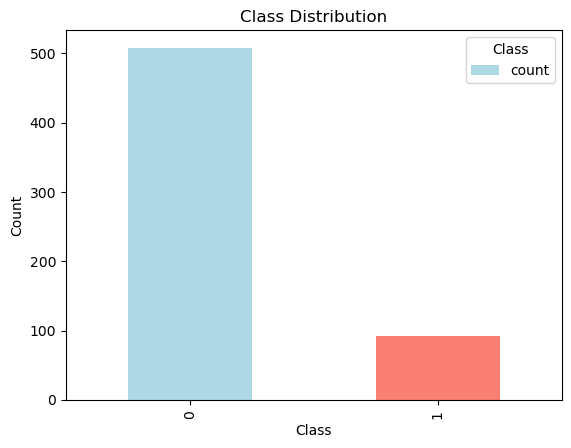

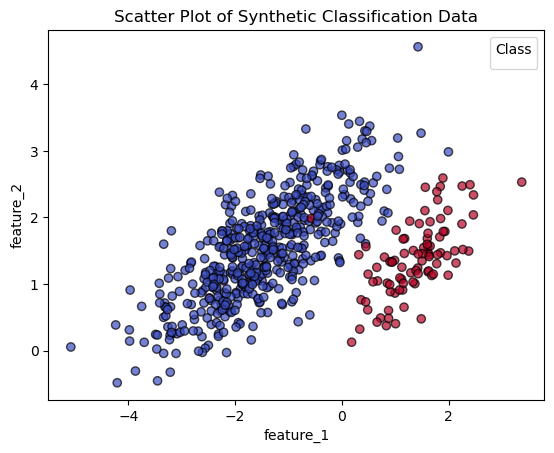

In [74]:
# TODO: צרו דאטה סינתטי לסיווג
X_cls, y_cls = make_classification(
    n_samples=600, 
    n_features=2,
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    weights=[0.85, 0.15],
    class_sep=1.5,
    random_state=42)

# TODO: צרו DataFrame ובדקו התפלגות מחלקות
cls_df = pd.DataFrame(X_cls, columns=["feature_1", "feature_2"])
cls_df["target"] = y_cls
print(cls_df["target"].value_counts())
#print(cls_df.head())

cls_df["target"].value_counts().sort_index().plot(kind="bar", color=["lightblue", "salmon"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.legend(title="Class")
plt.show()  

# TODO: ציירו class distribution ו-scatter plot
plt.scatter(cls_df["feature_1"], cls_df["feature_2"], c=cls_df["target"], cmap="coolwarm", edgecolor="k", alpha=0.7)
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Scatter Plot of Synthetic Classification Data")
plt.legend(*plt.gca().get_legend_handles_labels(), title="Class")
plt.show()

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
X_cls, y_cls = make_classification(
    n_samples=600,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.85, 0.15],
    class_sep=0.9,
    random_state=42,
)

cls_df = pd.DataFrame(X_cls, columns=["feature_1", "feature_2"])
cls_df["target"] = y_cls

print(cls_df["target"].value_counts())
print(cls_df["target"].value_counts(normalize=True))

cls_df["target"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

plt.scatter(cls_df["feature_1"], cls_df["feature_2"], c=cls_df["target"], alpha=0.8)
plt.xlabel("feature_1")
plt.ylabel("feature_2")
plt.title("Synthetic Classification Data")
plt.show()
```

כאשר הדאטה לא מאוזן, Accuracy יכול להיות מדד מטעה.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 8 — Decision Tree 

חלקו את הדאטה ל־train/test, ואז אמנו Decision Tree ללא הגבלת עומק.

בדקו:

1. Accuracy על train.
2. Accuracy על test.
3. האם יש סימנים ל־overfitting?

</div>

In [76]:
# TODO: train/test split
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# TODO: אמנו DecisionTreeClassifier ללא max_depth
deeptree = DecisionTreeClassifier(random_state=42)
deeptree.fit(X_train, y_train)

y_pred_train_cls = deeptree.predict(X_train)
y_pred_test_cls = deeptree.predict(X_test)

# TODO: חשבו accuracy על train/test
accuracy_train_cls = accuracy_score(y_train, y_pred_train_cls)
accuracy_test_cls = accuracy_score(y_test, y_pred_test_cls)

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls
)

deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_cls, y_train_cls)

train_acc = accuracy_score(y_train_cls, deep_tree.predict(X_train_cls))
test_acc = accuracy_score(y_test_cls, deep_tree.predict(X_test_cls))

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)
```

אם ה־train accuracy גבוה מאוד וה־test accuracy נמוך יותר, זה סימן אפשרי ל־overfitting.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 9 — ויזואליזציה של גבול החלטה

השוו בין:

1. עץ עמוק ללא הגבלת עומק.
2. עץ מוגבל עם `max_depth=3`.

ציירו Decision Boundary לכל אחד.

שאלה: איזה מודל נראה מורכב יותר?

</div>

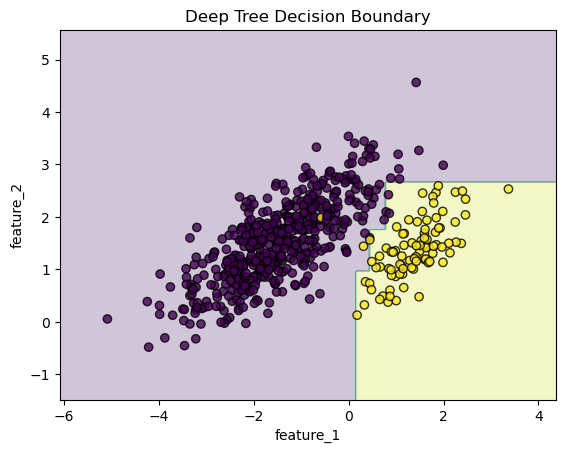

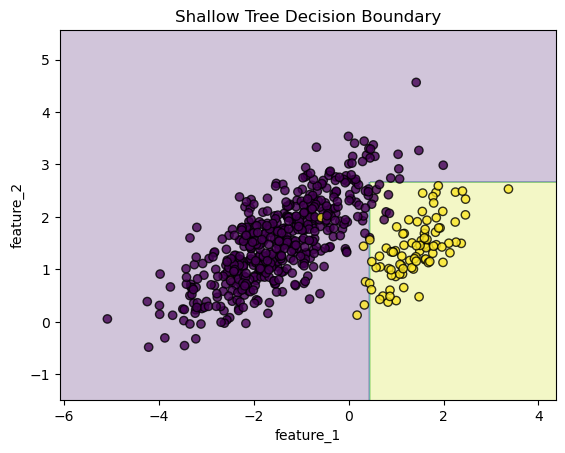

In [79]:
# TODO: אמנו shallow_tree עם max_depth=3
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
shallow_tree.fit(X_train, y_train)

# TODO: השתמשו בפונקציה plot_decision_boundary עבור deep_tree ועבור shallow_tree
plot_decision_boundary(deeptree, X_cls, y_cls, title="Deep Tree Decision Boundary")
plot_decision_boundary(shallow_tree, X_cls, y_cls, title="Shallow Tree Decision Boundary")

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train_cls, y_train_cls)

plot_decision_boundary(deep_tree, X_train_cls, y_train_cls, title="Deep Tree Decision Boundary")
plot_decision_boundary(shallow_tree, X_train_cls, y_train_cls, title="Shallow Tree Decision Boundary")

print("Deep tree test accuracy:", accuracy_score(y_test_cls, deep_tree.predict(X_test_cls)))
print("Shallow tree test accuracy:", accuracy_score(y_test_cls, shallow_tree.predict(X_test_cls)))
```

העץ העמוק יוצר גבול החלטה מורכב יותר ועלול להתאים לרעש.  
העץ הרדוד פשוט יותר ולעיתים מכליל טוב יותר.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 10 — Confusion Matrix ומדדי סיווג

עבור `shallow_tree`, חשבו:

- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1

שאלות:

1. מה ההבדל בין False Positive ל־False Negative?
2. מה חשוב יותר במקרה שבו המחלקה החיובית נדירה?
3. למה Accuracy לבד לא מספיק?

</div>

Deep Tree Train Accuracy: 1.0
Deep Tree Test Accuracy: 0.9666666666666667
Shallow Tree Train Accuracy: 0.9833333333333333
Shallow Tree Test Accuracy: 0.95
Confusion Matrix:
 [[99  3]
 [ 3 15]]


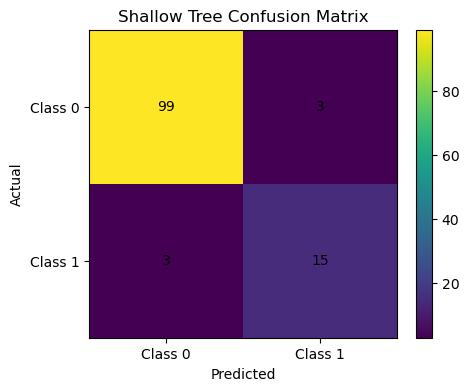

prescision: 0.8333333333333334
recall: 0.8333333333333334
f1 score: 0.8333333333333334


' TP = np.sum((y_test == 1) & (y_pred_test_cls == 1))\nTN = np.sum((y_test == 0) & (y_pred_test_cls == 0))\nFP = np.sum((y_test == 0) & (y_pred_test_cls == 1))\nFN = np.sum((y_test == 1) & (y_pred_test_cls == 0))\n\nprescision = TP / (TP + FP) # if (TP + FP) > 0 else 0\nrecall = TP / (TP + FN) # if (TP + FN) > 0 else 0\nf1 = 2 * (prescision * recall) / (prescision + recall) if (prescision + recall) > 0 else 0\nprint(f"Precision: {prescision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}") '

In [89]:
print("Deep Tree Train Accuracy:", accuracy_score(y_train, deeptree.predict(X_train)))
print("Deep Tree Test Accuracy:", accuracy_score(y_test, deeptree.predict(X_test)))
print("Shallow Tree Train Accuracy:", accuracy_score(y_train, shallow_tree.predict(X_train)))
print("Shallow Tree Test Accuracy:", accuracy_score(y_test, shallow_tree.predict(X_test)))  

# TODO: חשבו תחזיות על test

y_pred_tree = shallow_tree.predict(X_test)
cm = confusion_matrix(y_test, y_pred_tree)
print("Confusion Matrix:\n", cm)
plot_confusion_matrix_basic(cm, labels=["Class 0", "Class 1"], title="Shallow Tree Confusion Matrix")


# TODO: confusion matrix + metrics

print("prescision:", precision_score(y_test, y_pred_tree))
print("recall:", recall_score(y_test, y_pred_tree))
print("f1 score:", f1_score(y_test, y_pred_tree))

""" TP = np.sum((y_test == 1) & (y_pred_test_cls == 1))
TN = np.sum((y_test == 0) & (y_pred_test_cls == 0))
FP = np.sum((y_test == 0) & (y_pred_test_cls == 1))
FN = np.sum((y_test == 1) & (y_pred_test_cls == 0))

prescision = TP / (TP + FP) # if (TP + FP) > 0 else 0
recall = TP / (TP + FN) # if (TP + FN) > 0 else 0
f1 = 2 * (prescision * recall) / (prescision + recall) if (prescision + recall) > 0 else 0
print(f"Precision: {prescision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}") """

# TODO: ציירו confusion matrix

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
y_pred_tree = shallow_tree.predict(X_test_cls)

cm = confusion_matrix(y_test_cls, y_pred_tree)
print(cm)
plot_confusion_matrix_basic(cm, labels=("Class 0", "Class 1"), title="Shallow Tree Confusion Matrix")

print("Accuracy:", accuracy_score(y_test_cls, y_pred_tree))
print("Precision:", precision_score(y_test_cls, y_pred_tree))
print("Recall:", recall_score(y_test_cls, y_pred_tree))
print("F1:", f1_score(y_test_cls, y_pred_tree))
print(classification_report(y_test_cls, y_pred_tree))
```

Accuracy עונה: כמה צדקנו בסך הכל.  
Precision עונה: מתוך מה שסימנו כחיובי, כמה באמת חיובי.  
Recall עונה: מתוך כל החיוביים האמיתיים, כמה מצאנו.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 11 — Precision/Recall Tradeoff עם סף החלטה

מודלים רבים נותנים הסתברות למחלקה חיובית.  
ברירת המחדל היא לרוב סף 0.5:

- הסתברות ≥ 0.5 → מחלקה 1
- הסתברות < 0.5 → מחלקה 0

נבדוק מה קורה כאשר משנים את הסף.

משימות:

1. אמנו Logistic Regression.
2. קבלו הסתברויות למחלקה 1.
3. בדקו thresholds שונים: `0.2`, `0.5`, `0.8`.
4. השוו precision ו־recall.

</div>

In [91]:
# TODO: אמנו LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# TODO: קבלו probability למחלקה 1
y_pred_proba = logreg.predict_proba(X_test)[:, 1]  

# TODO: בדקו thresholds שונים וצרו טבלת metrics
thresholds = [0.2, 0.5, 0.8]
results = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    results.append({
         "threshold": thresh,         
         "precision": precision_score(y_test, y_pred_thresh),
         "recall": recall_score(y_test, y_pred_thresh)         
    })
results_df = pd.DataFrame(results)
print(results_df)


   threshold  precision    recall
0        0.2   0.809524  0.944444
1        0.5   1.000000  0.888889
2        0.8   1.000000  0.777778


<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
log_reg = LogisticRegression()
log_reg.fit(X_train_cls, y_train_cls)

y_proba = log_reg.predict_proba(X_test_cls)[:, 1]

thresholds = [0.2, 0.5, 0.8]
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_cls, y_pred_threshold),
        "precision": precision_score(y_test_cls, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test_cls, y_pred_threshold),
        "f1": f1_score(y_test_cls, y_pred_threshold),
    })

pd.DataFrame(threshold_results)
```

סף נמוך בדרך כלל מעלה recall אבל עלול להוריד precision.  
סף גבוה בדרך כלל מעלה precision אבל עלול להוריד recall.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 12 — ROC Curve ו־AUC

צרו ROC Curve עבור Logistic Regression וחשבו AUC.

שאלות:

1. מה מייצג ציר X?
2. מה מייצג ציר Y?
3. מה המשמעות של AUC גבוה?

</div>

In [ ]:
# TODO: חשבו fpr, tpr, thresholds עם roc_curve

# TODO: חשבו auc עם roc_auc_score

# TODO: ציירו ROC Curve

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
fpr, tpr, roc_thresholds = roc_curve(y_test_cls, y_proba)
auc = roc_auc_score(y_test_cls, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.show()
```

AUC מודד את יכולת המודל להפריד בין המחלקות על פני כל הספים.  
ערך קרוב ל־1 טוב יותר; ערך סביב 0.5 דומה לניחוש אקראי.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 13 — Cross Validation ובחירת עומק עץ

נבדוק עומקים שונים לעץ החלטה: `1` עד `10`.

משימות:

1. עבור כל עומק, בצעו 5-fold cross validation.
2. השתמשו במדד `f1`.
3. צרו טבלה עם ממוצע וסטיית תקן.
4. ציירו גרף של עומק מול F1 ממוצע.

</div>

In [ ]:
# TODO: cross validation עבור max_depth 1..10

<details dir="rtl">
<summary>פתרון מוסתר</summary>

```python
cv_results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(model, X_cls, y_cls, cv=5, scoring="f1")
    cv_results.append({
        "max_depth": depth,
        "mean_f1": scores.mean(),
        "std_f1": scores.std(),
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df)

plt.errorbar(cv_df["max_depth"], cv_df["mean_f1"], yerr=cv_df["std_f1"], marker="o")
plt.xlabel("max_depth")
plt.ylabel("Mean F1")
plt.title("Decision Tree Depth Selection with Cross Validation")
plt.show()
```

Cross Validation נותן הערכה יציבה יותר מאשר פיצול יחיד ל־train/test.  
עדיין חשוב לשמור test set סופי אם משתמשים ב־CV לבחירת מודל.

</details>

<div dir="rtl" style="text-align:right">

## שאלות סיכום

ענו בקצרה:

1. מה ההבדל בין מודל לינארי ב־x לבין מודל לינארי בפרמטרים?
2. למה פולינום מדרגה 3 עדיין ניתן לפתרון Least Squares?
3. מה ההבדל בין residual לבין error metric כמו RMSE?
4. איך מזהים underfitting?
5. איך מזהים overfitting?
6. למה Accuracy עלול להטעות בדאטה לא מאוזן?
7. מתי Precision חשוב יותר מ־Recall?
8. מתי Recall חשוב יותר מ־Precision?
9. מה ROC Curve מראה?
10. למה Cross Validation עוזר?

</div>